## Importing Necessary Pacakages

In [1]:
!pip install datasets
# !pip install googletrans==3.1.0a0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.7/472.7 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 15.4 MB/s eta 0:00:00


In [2]:
import requests
from PIL import Image
import torch
from transformers import BlipProcessor, BlipForQuestionAnswering,BlipImageProcessor, AutoProcessor
from transformers import BlipConfig
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import warnings

warnings.filterwarnings("ignore")

## Load Dataset

In [5]:
# # Load the VQA RAD dataset
# data_set = load_dataset("BoKelvin/SLAKE")

In [6]:
# data_set # View the datasetDict

In [7]:
# train_set = pd.DataFrame(data_set['train'])
# val_set = pd.DataFrame(data_set['validation'])
# test_set = pd.DataFrame(data_set['test'])

In [8]:
# df = pd.concat([train_set, val_set], ignore_index=True)

In [9]:
# df.head()

In [10]:
# # data which q_lang is chinese
# df_zh = df[df['q_lang'] == 'zh']
# df_zh.reset_index(drop=True, inplace=True)

In [11]:
# from googletrans import Translator

# # Translation function to handle each text item
# def translate_text(text):
#     translator = Translator()
#     try:
#         # Translate Chinese to English
#         translated = translator.translate(text, src='zh-cn', dest='en')
#         return translated.text
#     except Exception as e:
#         print(f"Translation error for '{text}': {e}")
#         return text  # Return the original text if translation fails

# # Function to translate a specific column in a DataFrame
# def translate_dataframe_column(df, column_name):
#     tqdm.pandas()
#     df[column_name] = df[column_name].progress_apply(translate_text)
#     return df

In [12]:
# df_translated = translate_dataframe_column(df = df_zh, column_name  = 'question')

In [13]:
# df_translated.head()

In [14]:
# df_translated = translate_dataframe_column(df = df_translated, column_name  = 'answer')

In [15]:
# df_en = df[df['q_lang'] == 'en']

# df = pd.concat([df_en, df_translated], ignore_index=True)

In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/model_ilab/data/

Mounted at /content/drive
/content/drive/MyDrive/model_ilab/data


In [49]:
# df read slake.csv and ignore Unnamed:0
df = pd.read_csv('slake.csv', index_col=0)

In [50]:
df.head()

,img_name,location,answer,modality,base_type,answer_type,question,qid,content_type,triple,img_id,q_lang
0,xmlab1/source.jpg,Abdomen,MRI,MRI,vqa,OPEN,What modality is used to take this image?,0,Modality,"['vhead', '_', '_']",1,en
1,xmlab1/source.jpg,Abdomen,Abdomen,MRI,vqa,OPEN,Which part of the body does this image belong to?,1,Position,"['vhead', '_', '_']",1,en
2,xmlab1/source.jpg,Abdomen,T2,MRI,vqa,OPEN,What is the mr weighting in this image?,2,Modality,"['vhead', '_', '_']",1,en
3,xmlab1/source.jpg,Abdomen,Yes,MRI,vqa,CLOSED,Does the picture contain liver?,3,Organ,"['vhead', '_', '_']",1,en
4,xmlab1/source.jpg,Abdomen,No,MRI,vqa,CLOSED,Does the picture contain kidney?,4,Organ,"['vhead', '_', '_']",1,en


In [51]:
df.isna().sum()

,0
img_name,0
location,0
answer,36
modality,0
base_type,0
answer_type,0
question,0
qid,0
content_type,0
triple,0


In [52]:
df.dropna(inplace=True)

In [53]:
%cd /content/drive/MyDrive/model_ilab/data/imgs

/content/drive/MyDrive/model_ilab/data/imgs


Question: What is the organ on the left side of this image?
Answer: Large Bowel


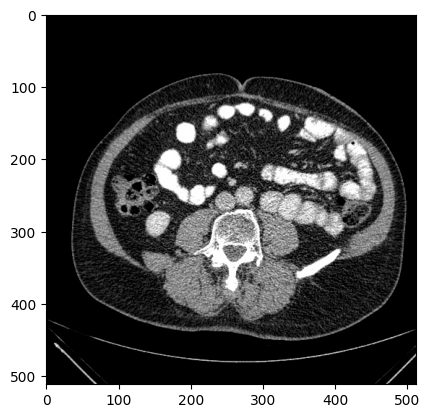

In [54]:
sample = df.sample(1).iloc[0]
img_path = sample['img_name']
image = Image.open(img_path)
PIL_image = Image.fromarray(np.array(image)).convert('RGB')
plt.imshow(image.convert('RGB'))
print("Question: {}".format(sample['question']))
print("Answer: {}".format(sample['answer']))

## Explore Data

In [55]:
df.shape #shape of data

(11898, 12)

In [56]:
df.head() #first 5 rows of data

,img_name,location,answer,modality,base_type,answer_type,question,qid,content_type,triple,img_id,q_lang
0,xmlab1/source.jpg,Abdomen,MRI,MRI,vqa,OPEN,What modality is used to take this image?,0,Modality,"['vhead', '_', '_']",1,en
1,xmlab1/source.jpg,Abdomen,Abdomen,MRI,vqa,OPEN,Which part of the body does this image belong to?,1,Position,"['vhead', '_', '_']",1,en
2,xmlab1/source.jpg,Abdomen,T2,MRI,vqa,OPEN,What is the mr weighting in this image?,2,Modality,"['vhead', '_', '_']",1,en
3,xmlab1/source.jpg,Abdomen,Yes,MRI,vqa,CLOSED,Does the picture contain liver?,3,Organ,"['vhead', '_', '_']",1,en
4,xmlab1/source.jpg,Abdomen,No,MRI,vqa,CLOSED,Does the picture contain kidney?,4,Organ,"['vhead', '_', '_']",1,en


In [57]:
config = BlipConfig.from_pretrained("Salesforce/blip-vqa-base")

In [58]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [59]:
class VQADataset(torch.utils.data.Dataset):
    def __init__(self, data, segment, text_processor, image_processor):
        self.data = data
        self.text_processor = text_processor
        self.image_processor = image_processor
        self.max_length = 32
        self.image_height = 128
        self.image_width = 128

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # get image + text
        answers = self.data.iloc[idx]['answer']
        question = self.data.iloc[idx]['question']
        image_path = self.data.iloc[idx]['img_name']
        image = Image.open(image_path)
        image = image.convert('RGB')
        text = question

        image_encoding = self.image_processor(image,
                                  do_resize=True,
                                  size=(self.image_height,self.image_width),
                                  return_tensors="pt")

        encoding = self.text_processor(
                                  None,
                                  text,
                                  padding="max_length",
                                  truncation=True,
                                  max_length = self.max_length,
                                  return_tensors="pt"
                                  )
        # # remove batch dimension
        for k,v in encoding.items():
            encoding[k] = v.squeeze()
        encoding["pixel_values"] = image_encoding["pixel_values"][0]
        # # add labels
        labels = self.text_processor.tokenizer.encode(
            answers,
            max_length= self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors='pt'
        )[0]
        encoding["labels"] = labels

        return encoding

In [60]:
text_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
image_processor = BlipImageProcessor.from_pretrained("Salesforce/blip-vqa-base")

In [61]:
train_vqa_dataset = VQADataset(data=train_df,
                     segment='train',
                     text_processor = text_processor,
                     image_processor = image_processor
                         )

val_vqa_dataset = VQADataset(data=val_df,
                     segment='validation',
                     text_processor = text_processor,
                     image_processor = image_processor
                         )

In [62]:
def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    pixel_values = [item['pixel_values'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    labels = [item['labels'] for item in batch]
    # create new batch
    batch = {}
    batch['input_ids'] = torch.stack(input_ids)
    batch['attention_mask'] = torch.stack(attention_mask)
    batch['pixel_values'] = torch.stack(pixel_values)
    batch['labels'] = torch.stack(labels)

    return batch

In [63]:
train_dataloader = DataLoader(train_vqa_dataset,
                              collate_fn=collate_fn,
                              batch_size=64,
                              shuffle=False)
val_dataloader = DataLoader(val_vqa_dataset,
                            collate_fn=collate_fn,
                            batch_size=64,
                            shuffle=False)

In [64]:
batch = next(iter(train_dataloader))
for key,value in batch.items():
    print(key, value.shape)

input_ids torch.Size([64, 32])
attention_mask torch.Size([64, 32])
pixel_values torch.Size([64, 3, 128, 128])
labels torch.Size([64, 32])


In [65]:
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base" )
model.to(device)

BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, e

In [66]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
image_mean = image_processor.image_mean
image_std = image_processor.image_std

Question:  [CLS] what is the organ located in the lower right corner? [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
Answer:  [CLS] spleen [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


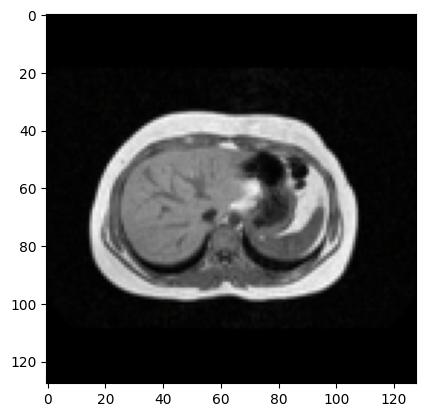

In [67]:
batch_idx = 1

unnormalized_image = (batch["pixel_values"][batch_idx].cpu().numpy() * np.array(image_std)[:, None, None]) + np.array(image_mean)[:, None, None]
unnormalized_image = np.moveaxis(unnormalized_image, 0, -1)
unnormalized_image = (unnormalized_image * 255).astype(np.uint8)

print("Question: ",text_processor.decode(batch["input_ids"][batch_idx]))
print("Answer: ",text_processor.decode(batch["labels"][batch_idx]))
plt.imshow(Image.fromarray(unnormalized_image))

In [68]:
val_loss = []
train_loss = []
min_val_loss = float('Inf')
num_epoch = 20

In [69]:
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# Assuming the rest of your model and data loader setup remains the same

# Define the early stopping criteria and scheduler
patience = 5  # Stop training after 'patience' epochs without improvement
early_stopping_counter = 0
min_val_loss = float('inf')  # Track the minimum validation loss

# Define learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)

In [70]:
df.tail()

,img_name,location,answer,modality,base_type,answer_type,question,qid,content_type,triple,img_id,q_lang
11929,xmlab99/source.jpg,Lung,"lungs, heart, liver",CT,vqa,OPEN,What are the main organs in the picture?,11929,Organ,"['vhead', '_', '_']",99,zh
11930,xmlab99/source.jpg,Lung,Include,CT,vqa,CLOSED,Does the picture contain liver?,11930,Organ,"['vhead', '_', '_']",99,zh
11931,xmlab99/source.jpg,Lung,Include,CT,vqa,CLOSED,Does the picture contain lungs?,11931,Organ,"['vhead', '_', '_']",99,zh
11932,xmlab99/source.jpg,Lung,Include,CT,vqa,CLOSED,Does the picture contain a heart?,11932,Organ,"['vhead', '_', '_']",99,zh
11933,xmlab99/source.jpg,Lung,no,CT,vqa,CLOSED,Are the lungs abnormal?,11933,Abnormality,"['vhead', '_', '_']",99,zh


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11898 entries, 0 to 11933
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   img_name      11898 non-null  object
 1   location      11898 non-null  object
 2   answer        11898 non-null  object
 3   modality      11898 non-null  object
 4   base_type     11898 non-null  object
 5   answer_type   11898 non-null  object
 6   question      11898 non-null  object
 7   qid           11898 non-null  int64 
 8   content_type  11898 non-null  object
 9   triple        11898 non-null  object
 10  img_id        11898 non-null  int64 
 11  q_lang        11898 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.2+ MB


In [72]:
print(train_df.isnull().sum())


img_name        0
location        0
answer          0
modality        0
base_type       0
answer_type     0
question        0
qid             0
content_type    0
triple          0
img_id          0
q_lang          0
dtype: int64


In [73]:
for epoch in range(num_epoch):
    model.train()
    total_loss = []

    for batch in tqdm(train_dataloader, desc=f"Epoch [{epoch+1}/{num_epoch}]"):
        # Move batch to device
        batch = {key: value.to(device) for key, value in batch.items()}

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(**batch)
        loss = outputs.loss
        total_loss.append(loss.item())

        # Backward pass and optimization step
        loss.backward()
        optimizer.step()

    # Calculate and store average training loss for this epoch
    avg_train_loss = sum(total_loss) / len(train_dataloader)
    train_loss.append(avg_train_loss)

    # Evaluate on validation set
    model.eval()
    total_val_loss = []
    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_val_loss.append(loss.item())

    # Calculate and store average validation loss for this epoch
    avg_val_loss = sum(total_val_loss) / len(val_dataloader)
    val_loss.append(avg_val_loss)

    # Adjust learning rate based on validation loss
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epoch} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    # Save the best model if validation loss improves
    if avg_val_loss < min_val_loss:
        min_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Validation loss decreased. Saving model...")
        early_stopping_counter = 0  # Reset counter for improvement
    else:
        early_stopping_counter += 1  # Increment counter if no improvement

    # Check for early stopping
    if early_stopping_counter >= patience:
        print(f"Early stopping after {epoch+1} epochs due to no improvement in validation loss.")
        break


Epoch [1/20]: 100%|██████████| 149/149 [04:48<00:00,  1.94s/it]


Epoch 1/20 - Train Loss: 2.7336 - Val Loss: 0.1244
Validation loss decreased. Saving model...


Epoch [2/20]: 100%|██████████| 149/149 [02:46<00:00,  1.12s/it]


Epoch 2/20 - Train Loss: 0.0872 - Val Loss: 0.0623
Validation loss decreased. Saving model...


Epoch [3/20]: 100%|██████████| 149/149 [02:49<00:00,  1.13s/it]


...

Epoch 15/20 - Train Loss: 0.0042 - Val Loss: 0.0241


Epoch [16/20]: 100%|██████████| 149/149 [02:43<00:00,  1.10s/it]


Epoch 16/20 - Train Loss: 0.0036 - Val Loss: 0.0240


Epoch [17/20]: 100%|██████████| 149/149 [02:42<00:00,  1.09s/it]


Epoch 17/20 - Train Loss: 0.0035 - Val Loss: 0.0241
Early stopping after 17 epochs due to no improvement in validation loss.


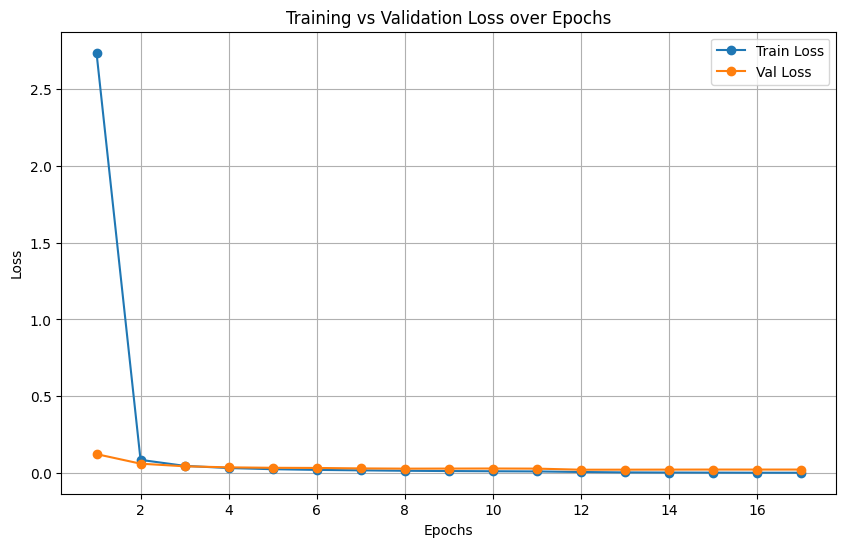

In [74]:
import matplotlib.pyplot as plt

# Create a list for the number of epochs (assuming num_epoch is the total number of epochs)
epochs = range(1, len(train_loss) + 1)

# Plotting the data
plt.figure(figsize=(10,6))
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Val Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss over Epochs')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

In [75]:
import nltk

nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

Question:  what modality is used to take this image?
Predicted Answer:  more
Actual Answer:  mri


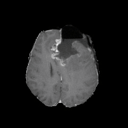

Question:  does the patient have brain tumor?
Predicted Answer:  no
Actual Answer:  yes


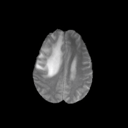

Question:  what organ marks the lower end of the organ system?
Predicted Answer:  man
Actual Answer:  mandible


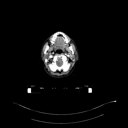

Question:  which one is bigger, the lungs, heart or liver in the picture?
Predicted Answer:  lung
Actual Answer:  lung


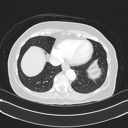

Question:  what diseases are included in the picture?
Predicted Answer:  brain edema, brain tumor
Actual Answer:  brain tumor, cerebral edema


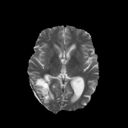

Question:  which is abnormal, the lungs or the heart?
Predicted Answer:  heart
Actual Answer:  heart


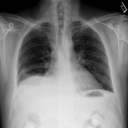

Question:  what color does the spinal cord show in the picture?
Predicted Answer:  more
Actual Answer:  gray


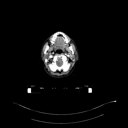

Question:  what color is the lung in the picture?
Predicted Answer:  black
Actual Answer:  black


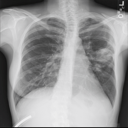

Question:  does the picture include the spleen?
Predicted Answer:  more
Actual Answer:  include


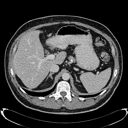

Question:  what is the mr weighting in this image?
Predicted Answer:  t2
Actual Answer:  t2


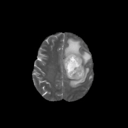

In [80]:
# add batch dimension + move to GPU|
for x in range(10):
    random_10_int = np.random.randint(0, len(val_vqa_dataset))
    random_index = x + random_10_int
    sample = val_vqa_dataset[random_index]
    print("Question: ",text_processor.decode(sample['input_ids'], skip_special_tokens=True))
    sample = {k: v.unsqueeze(0).to(device) for k,v in sample.items()}

    # forward pass
    outputs = model.generate(pixel_values=sample['pixel_values'],
                            input_ids=sample['input_ids'])
    print("Predicted Answer: ",text_processor.decode(outputs[0],skip_special_tokens=True))
    print("Actual Answer: ",text_processor.decode(sample['labels'][0], skip_special_tokens=True))
    unnormalized_image = (sample["pixel_values"][0].cpu().numpy() * np.array(image_std)[:, None, None]) + np.array(image_mean)[:, None, None]
    unnormalized_image = (unnormalized_image * 255).astype(np.uint8)
    unnormalized_image = np.moveaxis(unnormalized_image, 0, -1)
    display(Image.fromarray(unnormalized_image))

In [77]:
# Initialize total loss and BLEU score metric
total_loss = 0
predictions = []
references = []

In [78]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Function to calculate BLEU-1 to BLEU-4 on the entire validation set
def calculate_bleu_scores(val_vqa_dataset, model, text_processor, device):
    total_bleu1 = 0.0
    total_bleu2 = 0.0
    total_bleu3 = 0.0
    total_bleu4 = 0.0
    num_samples = len(val_vqa_dataset)
    smoothing_fn = SmoothingFunction().method1  # To avoid division by zero in small datasets

    for idx in range(num_samples):
        # Load sample and move to GPU
        sample = val_vqa_dataset[idx]
        sample = {k: v.unsqueeze(0).to(device) for k, v in sample.items()}

        # Generate model's predicted output
        outputs = model.generate(pixel_values=sample['pixel_values'],
                                 input_ids=sample['input_ids'])

        # Decode predicted and actual answers
        predicted_answer = text_processor.decode(outputs[0], skip_special_tokens=True)
        actual_answer = text_processor.decode(sample['labels'][0], skip_special_tokens=True)

        # Tokenize both the reference and predicted answers
        reference = actual_answer.split()
        candidate = predicted_answer.split()

        # Calculate BLEU scores for 1-gram to 4-gram
        bleu1 = sentence_bleu([reference], candidate, weights=(1, 0, 0, 0), smoothing_function=smoothing_fn)
        bleu2 = sentence_bleu([reference], candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing_fn)
        bleu3 = sentence_bleu([reference], candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing_fn)
        bleu4 = sentence_bleu([reference], candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing_fn)

        # Accumulate the BLEU scores
        total_bleu1 += bleu1
        total_bleu2 += bleu2
        total_bleu3 += bleu3
        total_bleu4 += bleu4

    # Calculate the average BLEU scores for the validation set
    avg_bleu1 = total_bleu1 / num_samples
    avg_bleu2 = total_bleu2 / num_samples
    avg_bleu3 = total_bleu3 / num_samples
    avg_bleu4 = total_bleu4 / num_samples

    # Print the final average BLEU-1 to BLEU-4 scores
    print(f"Average BLEU-1 Score: {avg_bleu1:.4f}")
    print(f"Average BLEU-2 Score: {avg_bleu2:.4f}")
    print(f"Average BLEU-3 Score: {avg_bleu3:.4f}")
    print(f"Average BLEU-4 Score: {avg_bleu4:.4f}")

In [79]:
# Example usage
calculate_bleu_scores(val_vqa_dataset, model, text_processor, device)

Average BLEU-1 Score: 0.4351
Average BLEU-2 Score: 0.1868
Average BLEU-3 Score: 0.1278
Average BLEU-4 Score: 0.1021


In [5]:
%cd /content/drive/MyDrive/model_ilab

/content/drive/MyDrive/model_ilab


In [1]:
from transformers import BlipProcessor, BlipForQuestionAnswering
import torch

# Path to the saved model and processor
model_save_path = "./blip_finetuned_model_27_Oct_v2"

# save model
# model.save_pretrained(model_save_path)

# save processor
# text_processor.save_pretrained(model_save_path)

In [6]:
from transformers import BlipProcessor, BlipForQuestionAnswering
import torch

# Load the fine-tuned model and processor
processor = BlipProcessor.from_pretrained(model_save_path)
loaded_model = BlipForQuestionAnswering.from_pretrained(model_save_path)

# Move the model to GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)

BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, e

Saving bd937738ad6223a03f8aedcf4920a7_big_gallery.jpeg to bd937738ad6223a03f8aedcf4920a7_big_gallery.jpeg


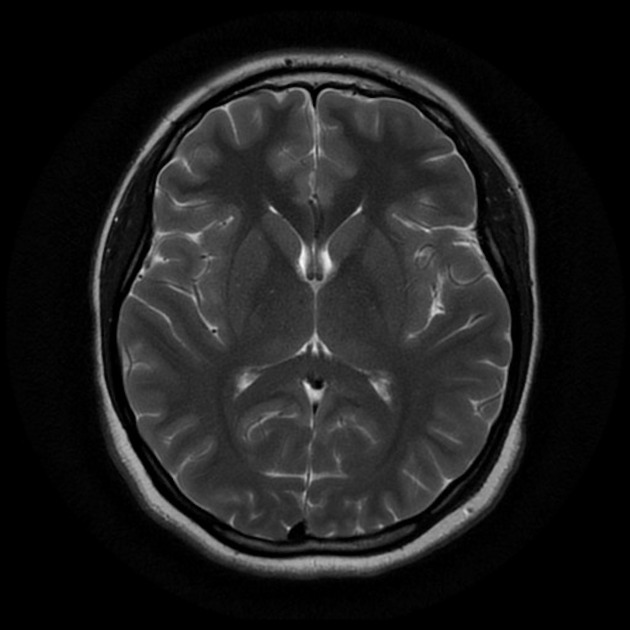

Enter your question: what is this?


/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1258: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Predicted Answer: brain
Enter your question: is this liver?
Predicted Answer: no
Enter your question: what has happened to brain?
Predicted Answer: brain edema, brain enhancing tumor, brain non - enhancing tumor
Enter your question: is there tumor?
Predicted Answer: yes
Enter your question: which side is tumor?
Predicted Answer: right
Enter your question: exit


In [7]:
from PIL import Image

# Replace with your image path in Google Drive
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Open the image
image = Image.open(image_path)
display(image)

# Question prompt
while True:
  question = str(input("Enter your question: "))

  if question == "exit":
    break
  # Preprocess the image and question using the processor
  inputs = processor(image, question, return_tensors="pt").to("cuda")

  # Forward pass to generate the output (move to GPU and generate)
  with torch.no_grad():
      outputs = loaded_model.generate(pixel_values=inputs['pixel_values'],
                              input_ids=inputs['input_ids'])

  # Decode the predicted answer
  predicted_answer = processor.decode(outputs[0], skip_special_tokens=True)

  print(f"Predicted Answer: {predicted_answer}")